In [12]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent
%matplotlib inline

In [13]:
EJ = 3
EC = 0.6
EL = 0.13
Er = 7.2622522
g_strength = 0.3

qubit_level = 15
osc_level = 50


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=Er,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
energies=  hilbertspace.eigenvals(qubit_level*osc_level)


In [14]:
products_to_keep = []

for ql in range(15):
    for ol in range(40):
        products_to_keep.append([ql,ol])


def truncate_function(qobj):
    return truncate_custom(qobj, products_to_keep, product_to_dressed)


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
a_trunc = truncate_function(a)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])
diag_dressed_hamiltonian = truncate_function(diag_dressed_hamiltonian)

w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)],product_to_dressed[(0,1)] ) 

tot_time =500
tlist = np.linspace(0, tot_time, tot_time)

amp = 0.004


In [15]:
def write_function():
    if os.path.exists('temp_functions.py'):
        os.remove('temp_functions.py')
    with open('temp_functions.py', 'w') as f:
        f.write(f"""
from utils import *
            
w_d = {w_d}
amp = {amp}

product_to_dressed = {product_to_dressed}
products_to_keep = {products_to_keep}
def square_cos(t, *args):
    cos = np.cos(w_d * 2 * np.pi * t)
    return 2 * np.pi * amp * cos
    

def pad_back_custom(qobj: qutip.Qobj, products_to_keep: list, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, oscillator_level), dressed_level in product_to_dressed.items() if [qubit_level, oscillator_level] in products_to_keep]
    indices_to_keep.sort()

    full_dimension = max(product_to_dressed.values()) + 1

    if qobj.shape[1] == 1:  # is ket
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[indices_to_keep, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[np.ix_(indices_to_keep, indices_to_keep)] = qobj.full()
        return qutip.Qobj(padded_matrix)

def mesolve_and_pad(rho0,
            H_with_drive,
             tlist, 
            full_dim,
            c_ops = None
            ):

    temp = qutip.mesolve(
        H=H_with_drive,
        rho0=rho0,
        tlist=tlist,
        c_ops=c_ops,
        options=qutip.Options(store_states=True, nsteps=20000, num_cpus=1),
        progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
    )

    # padded_states = [pad_back(state, full_dim) for state in temp.states]
    
    padded_states = [pad_back_custom(state, products_to_keep, product_to_dressed) for state in temp.states]
    return CustomOdeResult(times=temp.times, states=padded_states)
""")
write_function()


In [16]:

from temp_functions import mesolve_and_pad, square_cos
H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos],
]

results = [None] * 4
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(mesolve_and_pad, 
                               rho0=truncate_function(qutip.basis(hilbertspace.dimension, product_to_dressed[(i, 0)])), 
                               H_with_drive=H_with_drive,
                               tlist=tlist, 
                               full_dim=hilbertspace.dimension,
                               ): i for i in range(4)}
    
    for future in concurrent.futures.as_completed(futures):
        original_index = futures[future]
        results[original_index] = future.result()


import pickle
with open('sesolve_detection_results_verify_qubit_transi_small_drive.pkl', 'wb') as file:
    pickle.dump(results, file)


 Total run time: 1316.91s] Elapsed 1316.91s / Remaining 00:00:00:00         0%           ] Elapsed 0.00s / Remaining 00:00:00:00
 Total run time: 1419.61s] Elapsed 1419.61s / Remaining 00:00:00:00
 Total run time: 1421.56s] Elapsed 1421.56s / Remaining 00:00:00:00
 Total run time: 1431.18s] Elapsed 1431.18s / Remaining 00:00:00:00


In [12]:
with open('sesolve_detection_results_verify_qubit_transi_small_drive.pkl', 'rb') as file:
    results = pickle.load(file)

In [17]:


lists = []
for ql in [0,1,2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(qubit_level):
            if q != ql:
                for o in range(osc_level):
                    product_state = (q, o)
                    dressed_state = product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    print(pop_list)
    lists.append(pop_list)


t loop:   0%|          | 0/500 [00:00<?, ?it/s]

[0.0, 1.215268451722966e-06, 3.1078907413074383e-06, 2.702858946099482e-06, 6.841674344408689e-07, 1.0278625472513045e-07, 1.833224853507487e-06, 3.94010786845577e-06, 4.080598042754021e-06, 3.8120982057182543e-06, 2.520287468507075e-06, 6.166112715579069e-06, 5.425257981473035e-06, 5.409278664995168e-06, 2.3622871370704677e-06, 4.812477570737936e-06, 5.274340552591667e-06, 6.828964743517276e-06, 3.415435125756474e-06, 3.959251177033496e-06, 3.941211014609359e-06, 7.104982535117575e-06, 4.921408018061521e-06, 4.470529337012553e-06, 2.672909391373499e-06, 6.050711930918536e-06, 5.677328828135156e-06, 5.914073603244476e-06, 2.6345030086555127e-06, 2.1523310933939205e-06, 5.414981547156893e-06, 4.865626154661426e-06, 4.47584185660717e-06, 1.9403081131547245e-06, 4.40426585890815e-06, 5.042746994713645e-06, 6.254339937106196e-06, 3.020047189599929e-06, 3.6190442737418187e-06, 3.966097982289485e-06, 6.857661278831866e-06, 4.756770840011104e-06, 4.107927586858667e-06, 2.7862277451353434e-06,

t loop:   0%|          | 0/500 [00:00<?, ?it/s]

[0.0, 1.3067196399975193e-06, 4.896268427495247e-06, 1.0371814050746465e-05, 1.6693118628789965e-05, 2.1992806183055275e-05, 2.239276515090116e-05, 2.2889444700878397e-05, 1.8296652316854554e-05, 1.4928105057128084e-05, 8.484200071196557e-06, 5.911555982959234e-06, 2.455936324885217e-06, 4.601220407537382e-06, 6.015781531300327e-06, 1.2306312430200135e-05, 1.571957419848924e-05, 2.1647185665428728e-05, 2.222280537801803e-05, 2.3667804978071463e-05, 1.9289883996770232e-05, 1.6448222942873878e-05, 9.785712689991283e-06, 6.949291786260158e-06, 2.8960742694168027e-06, 4.279463978725434e-06, 5.23134056096718e-06, 8.5229645111893e-06, 1.4784850622353292e-05, 1.8175602665520554e-05, 2.2172107691524085e-05, 2.1438121881375696e-05, 2.053680232483315e-05, 1.540338505169419e-05, 1.1749458292285192e-05, 6.135722213992337e-06, 4.527795090675218e-06, 2.7001937502358847e-06, 5.919489256505767e-06, 8.339135085291537e-06, 1.4511707343344191e-05, 1.745384643762869e-05, 2.1945359842436295e-05, 2.12037691

t loop:   0%|          | 0/500 [00:00<?, ?it/s]

[0.0, 2.9110740046684137e-07, 6.07396792618198e-07, 9.094092449607773e-07, 1.969801062103395e-06, 3.5458627489161345e-06, 2.107144621405556e-06, 3.5242556376728493e-06, 2.4812719766954787e-06, 4.340815340337359e-06, 2.6271417749941905e-06, 3.881661260969037e-06, 2.5245343584747938e-06, 4.153124403969947e-06, 2.6183011978231796e-06, 4.346127214696795e-06, 3.0184997668197307e-06, 4.1928461322519685e-06, 2.4044828927502923e-06, 4.164764164825612e-06, 2.962843635920999e-06, 4.3567452570312745e-06, 2.84483778967532e-06, 4.372448730254398e-06, 2.6718384538781953e-06, 3.957780377932258e-06, 2.852479582087513e-06, 4.606197558570812e-06, 2.9304137591282717e-06, 1.7566035040681602e-06, 3.0947133677584224e-06, 2.048833407763158e-06, 3.2881097814435002e-06, 2.449478651180731e-06, 3.948215397913145e-06, 2.4387075190587205e-06, 3.470915816390249e-06, 2.4762312883708383e-06, 4.0156038025551235e-06, 2.731648501026363e-06, 4.139445986037042e-06, 2.949568486931293e-06, 3.9994215730587074e-06, 2.54761207

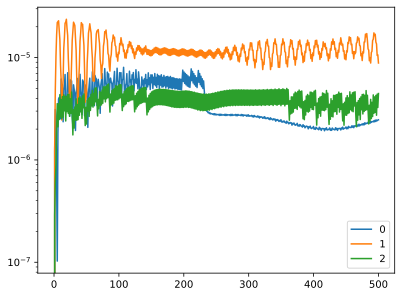

In [18]:
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()

In [19]:
from matplotlib.colors import LogNorm
def plot_heatmap(result, time_index, product_to_dressed, qubit_levels, oscillator_levels):
    if hasattr(result, 'states'):
        dm = result.states[time_index]
    elif hasattr(result, 'y'):
        dm = result.y[time_index]

    # dm = pad_back_function(dm)
    grid = np.zeros(( qubit_levels,oscillator_levels))

    for qubit_level in range(qubit_levels):
        for oscillator_level in range(oscillator_levels):
            product_state = (qubit_level, oscillator_level)
            dressed_state = product_to_dressed[product_state]
            if dressed_state < dm.dims[0][0]:
                # Create a basis state corresponding to the dressed state
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                # Calculate the expectation value
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
            else:
                expectation_value = 0
            grid[ qubit_level,oscillator_level] = expectation_value
    grid[grid < 1e-11] = 1e-11
    plt.imshow(grid, cmap='viridis', origin='lower',norm=LogNorm())
    plt.colorbar(label='Expectation Value')
    plt.xlabel('Oscillator Level')
    plt.ylabel('Qubit Level')
    
    plt.title(f'Expectation Values at t = {result.times[time_index]}')
    plt.show()

def interactive_heatmap(result, product_to_dressed, qubit_levels, oscillator_levels):
    if hasattr(result, 'times'):
        times = result.times
    elif hasattr(result, 't'):
        times = result.t
    time_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(times) - 1,
        step=1,
        description='Time Index:',
        continuous_update=False
    )
    
    widgets.interact(lambda time_index: plot_heatmap(result, time_index, product_to_dressed, qubit_levels, oscillator_levels),
                     time_index=time_slider)
    

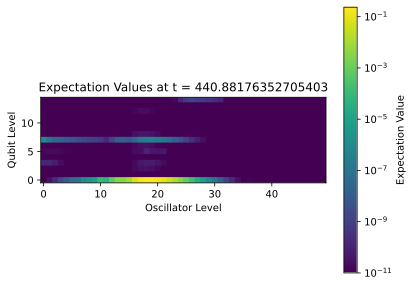

In [20]:
plot_heatmap(results[0], time_index=440, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

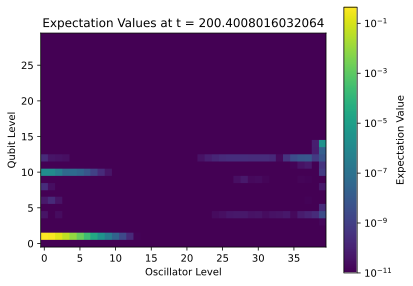

In [10]:
plot_heatmap(results[1], time_index=200, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

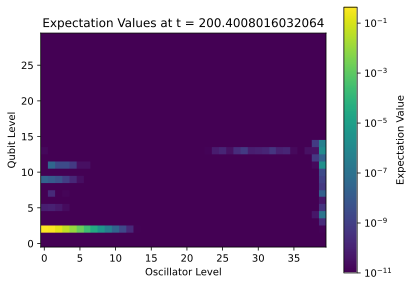

In [11]:
plot_heatmap(results[2], time_index=200, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)